# Preprocessing

Important imports

In [585]:
import numpy as np
import os

np.random.seed(123) # REMOVEME

## Loading dataset

### Loading string data

**Parameters:**
- `data_string`: A string containing the data in the format:
  - First line: number of jobs and number of machines (e.g., "10 10")
  - Following lines: for each job, alternating machine numbers and processing times

**Returns:**
- `np.ndarray`: A numpy array of shape `(num_jobs, num_machines, 2)` where the last dimension is `[machine, time]` pairs.

In [586]:
def load_from_string(data_string):
    lines = data_string.strip().split('\n')
    
    num_jobs, num_machines = map(int, lines[0].split())
    
    data = []
    for i in range(1, num_jobs + 1):
        nums = list(map(int, lines[i].split()))
        pairs = [[nums[j], nums[j+1]] for j in range(0, len(nums), 2)]
        data.append(pairs)
    
    return np.array(data)

### Loading txt file

**Parameters:**
- `key`: The instance key (e.g., 'abz5', 'ft06', 'la01') to load from the dataset.
- `filepath`: Path to the jobshop.txt file. Default is `./data/jobshop.txt`.

**Returns:**
- `np.ndarray`: A numpy array of shape `(num_jobs, num_machines, 2)` where the last dimension is `[machine, time]` pairs.

In [587]:
def load_from_dataset(key, filepath=os.path.join('.', 'data', 'jobshop.txt')):    
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Dataset file not found at {filepath}")
    
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    instance_marker = f'instance {key}'
    start_idx = None
    
    for i, line in enumerate(lines):
        if instance_marker in line:
            start_idx = i
            break
    
    if start_idx is None:
        raise ValueError(f"Instance '{key}' not found in the dataset")
    
    dimensions_line = None
    data_start_idx = None
    
    for i in range(start_idx, min(start_idx + 10, len(lines))):
        line = lines[i].strip()
        if line and line[0].isdigit():
            parts = line.split()
            if len(parts) >= 2 and all(p.isdigit() for p in parts[:2]):
                dimensions_line = line
                data_start_idx = i + 1
                break
    
    if dimensions_line is None:
        raise ValueError(f"Could not parse dimensions for instance '{key}'")
    
    num_jobs, num_machines = map(int, dimensions_line.split()[:2])
    
    data = []
    for i in range(data_start_idx, data_start_idx + num_jobs):
        if i < len(lines):
            line = lines[i].strip()
            if line and not line.startswith('+'):
                nums = list(map(int, line.split()))
                pairs = [[nums[j], nums[j+1]] for j in range(0, len(nums), 2)]
                data.append(pairs)
    
    if len(data) != num_jobs:
        raise ValueError(f"Expected {num_jobs} jobs, but found {len(data)}")
    
    return np.array(data)

---

# Algorithms

## Evolution Strategy (μ + λ) 

### Data representation

An individual is a **permutation** of length `num_jobs * num_machines`, where each job index appears exactly `num_machines` times.

In [588]:
def create_individual(num_jobs, num_machines):
    individual = np.repeat(np.arange(num_jobs), num_machines)
    np.random.shuffle(individual)
    return individual

def create_population(size, num_jobs, num_machines):
    return [create_individual(num_jobs, num_machines) for _ in range(size)]

### Fitness function

The fitness function is **makespan** -> total completion time of all jobs. Since we are trying to minimize completition time -> **lower makespan = better fitness**.

In [589]:
def compute_makespan(individual, data):
    num_jobs, num_machines, _ = data.shape
    
    job_op_count = np.zeros(num_jobs, dtype=int)
    job_end_time = np.zeros(num_jobs, dtype=int)
    machine_end_time = np.zeros(num_machines, dtype=int)
    
    for gene in individual:
        j = gene
        k = job_op_count[j]
        machine_id, proc_time = data[j, k, :]
        
        start = max(job_end_time[j], machine_end_time[machine_id])
        end = start + proc_time
        
        job_end_time[j] = end
        machine_end_time[machine_id] = end
        job_op_count[j] += 1
    
    return np.max(job_end_time)

### Swap Mutation

For mutation we pick two random positions and swap their values. This also ensures that each job still appears the correct number of times  

The **step size** controls mutation strength by determining **how many swaps** to perform. Larger step size means more mutations (more exploration), while smaller step size results in more exploitation

In [590]:
def mutate(individual, sigma):
    child = individual.copy()
    num_swaps = max(1, int(sigma + 0.5))
    length = len(child)
    
    for _ in range(num_swaps):
        i, j = np.random.randint(0, length, size=2)
        child[i], child[j] = child[j], child[i]
    
    return child

### Self-Adaptation

**Rechenberg's 1/5 Success Rule** adapts the mutation strenght based on success rate:

- **Success rate > 1/5**: Too much exploitation - more than 1/5 offspring are better than the parents -> **increase** the mutation strength  
- **Success rate < 1/5**: Too much exploration - more than 1/5 offspring are better than the parents -> **decrease** the mutation strength  
- **Success rate = 1/5**: don't change anything  

In [591]:
def self_adaptation(sigma, success_count, total_offspring, c, sigma_min=1.0, sigma_max=float('inf')):
    if total_offspring == 0:
        return sigma
    
    success_rate = success_count / total_offspring
    
    if success_rate > 0.2:
        sigma = sigma / c
    elif success_rate < 0.2:
        sigma = sigma * c

    return np.clip(sigma, sigma_min, sigma_max)

### Main loop

Implementation of **Algorithm 19** from the Essentials of Metaheuristics by Sean Luke

In [592]:
def evolution_strategy(data, mu, lam, max_generations, c=0.85):
    num_jobs, num_machines, _ = data.shape
    genome_length = num_jobs * num_machines
    sigma = genome_length / 10
    sigma_min = 1.0
    sigma_max = genome_length / 2
    
    population = create_population(mu + lam, num_jobs, num_machines)
    fitness = [compute_makespan(ind, data) for ind in population]
    
    best_idx = np.argmin(fitness)
    best_individual = population[best_idx].copy()
    best_makespan = fitness[best_idx]
    history = [best_makespan]
    
    for gen in range(max_generations):
        sorted_indices = np.argsort(fitness)[:mu]
        parents = [population[i] for i in sorted_indices]
        parent_fitness = [fitness[i] for i in sorted_indices]
        
        offspring_per_parent = lam // mu
        offspring = []
        offspring_fitness = []
        success_count = 0
        
        for p_idx in range(mu):
            for _ in range(offspring_per_parent):
                child = mutate(parents[p_idx], sigma)
                child_fit = compute_makespan(child, data)
                offspring.append(child)
                offspring_fitness.append(child_fit)
                if child_fit < parent_fitness[p_idx]:
                    success_count += 1
        
        remainder = lam - offspring_per_parent * mu
        for r in range(remainder):
            p_idx = r % mu
            child = mutate(parents[p_idx], sigma)
            child_fit = compute_makespan(child, data)
            offspring.append(child)
            offspring_fitness.append(child_fit)
            if child_fit < parent_fitness[p_idx]:
                success_count += 1
        
        population = parents + offspring
        fitness = parent_fitness + offspring_fitness
        
        total_offspring = len(offspring)
        sigma = self_adaptation(sigma, success_count, total_offspring, c, sigma_min, sigma_max)
        
        gen_best_idx = np.argmin(fitness)
        if fitness[gen_best_idx] < best_makespan:
            best_individual = population[gen_best_idx].copy()
            best_makespan = fitness[gen_best_idx]
        
        history.append(best_makespan)
    
    return best_individual, best_makespan, history

---

# Visualizations

## Evolution Strategy

Running multiple datasets of different sizes to observe results and computation time

[ft06] (6 jobs, 6 machines)
[ft06] Best makespan found: 55, finished in 1.46 seconds


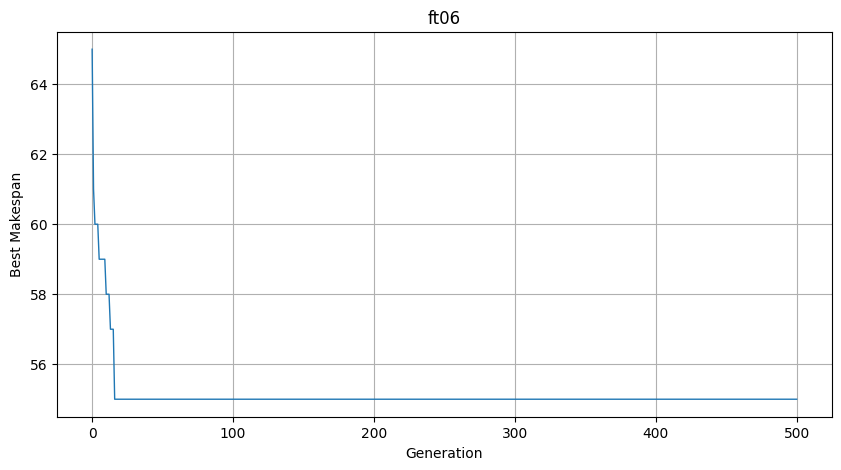

[abz5] (10 jobs, 10 machines)
[abz5] Best makespan found: 1282, finished in 3.75 seconds


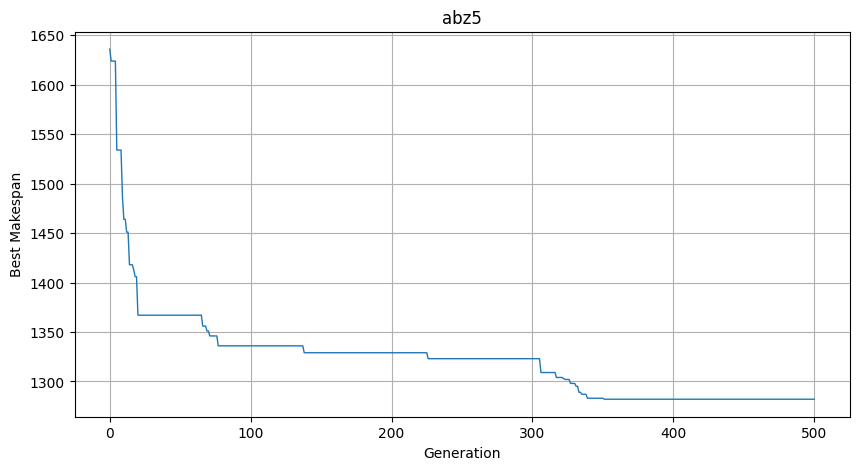

[la36] (15 jobs, 15 machines)
[la36] Best makespan found: 1388, finished in 7.90 seconds


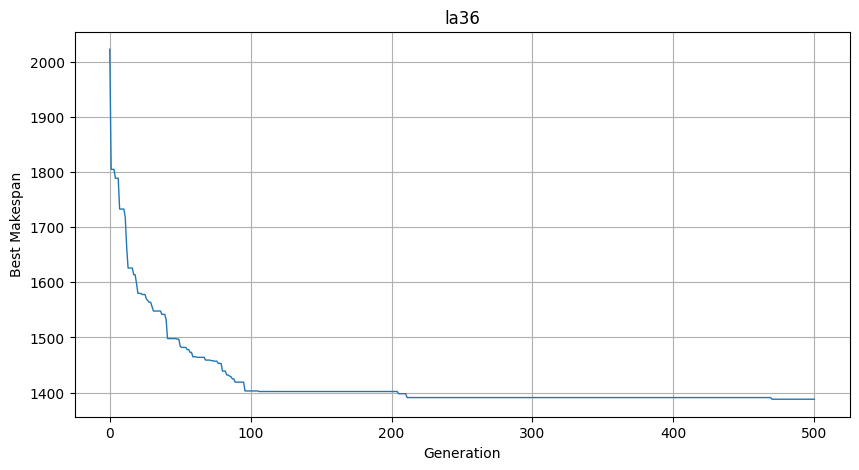

[swv10] (20 jobs, 15 machines)
[swv10] Best makespan found: 2057, finished in 10.35 seconds


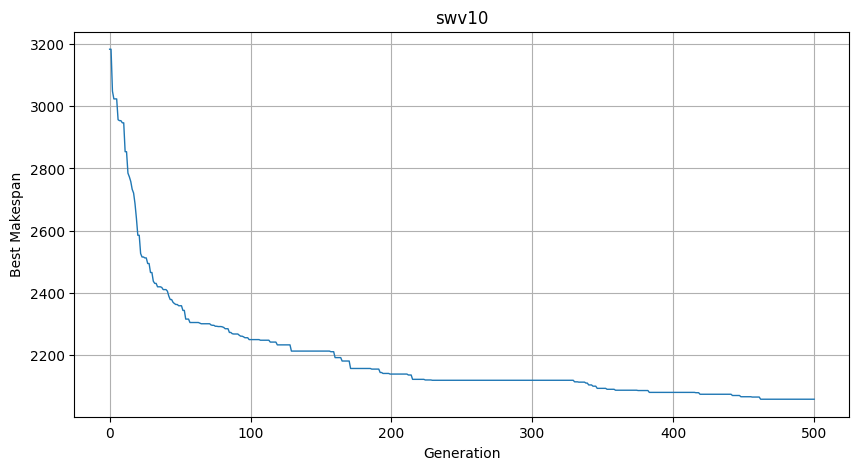

In [593]:
import time
import matplotlib.pyplot as plt

all_histories = []

for dataset_name in ['ft06', 'abz5', 'la36', 'swv10']:
    data = load_from_dataset(dataset_name)
    num_jobs, num_machines, _ = data.shape
    print(f"[{dataset_name}] ({num_jobs} jobs, {num_machines} machines)")

    start_time = time.time()
    best_individual, best_makespan, history = evolution_strategy(data, mu=10, lam=70, max_generations=500)
    elapsed_time = time.time() - start_time

    print(f"[{dataset_name}] Best makespan found: {best_makespan}, finished in {elapsed_time:.2f} seconds")

    label = f"{dataset_name} ({num_jobs} x {num_machines})"
    all_histories.append((history, label))

    plt.figure(figsize=(10, 5))
    plt.plot(history, linewidth=1)
    plt.xlabel('Generation')
    plt.ylabel('Best Makespan')
    plt.title(f'{dataset_name}')
    plt.grid(True)
    plt.show()

### Normalised plot

Multiple runs showed that smaller datasets (usually) need much less generations than for larger datasets to get better results. Results were not as stable as expected though, sometimes even smallest dataset took much more generations to get best result.

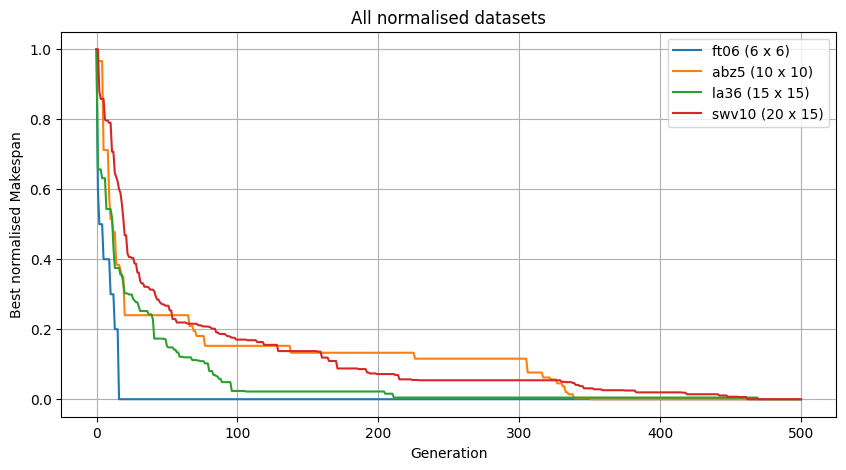

In [594]:
plt.figure(figsize=(10, 5))
for history, label in all_histories:
    arr = np.array(history)
    min_val, max_val = arr.min(), arr.max()
    norm = (arr - min_val) / (max_val - min_val)
    plt.plot(norm, label=label)
plt.xlabel('Generation')
plt.ylabel('Best normalised Makespan')
plt.title('All normalised datasets')
plt.legend()
plt.grid(True)
plt.show()

---

# Results